In [7]:
#ouvre les csv de Final_data / pic_activité 
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Chemin vers le dossier contenant les fichiers CSV
folder_path = '../Final_data/pics_activité'
# Liste pour stocker les DataFrames
dataframes = []
# Parcourir tous les fichiers dans le dossier
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        print(f'Loading {filename}')


Loading bronchiolite-passages-aux-urgences-et-actes-sos-medecins-departement.csv
Loading covid-19-passages-aux-urgences-et-actes-sos-medecins-departement.csv
Loading grippe-passages-aux-urgences-et-actes-sos-medecins-departement.csv
Loading infections-respiratoires-aigues-ira-passages-aux-urgences-et-actes-sos-medecins-departement.csv


In [12]:
#à partir des nom de fichier ouvrir convid-19_data et afficher les données

#ouvrir le csv 
filename = 'covid-19-passages-aux-urgences-et-actes-sos-medecins-departement.csv'
file_path = os.path.join('../Final_data/pics_activité', filename)
# Le fichier utilise des virgules comme séparateur — enlever sep=';' qui provoquait une seule colonne.
covid_data = pd.read_csv(file_path)  # default sep=','
# nettoyer les noms de colonnes (espaces ou BOM éventuel)
covid_data.columns = [c.strip().lstrip('\ufeff') for c in covid_data.columns]

#Département 75 Paris
paris_data = covid_data[covid_data['Département'] == "Paris"]
print(paris_data.head())


      1er jour de la semaine   Semaine Département Code Département  \
23935             2019-12-30  2020-S01               75       Paris   
23936             2020-01-06  2020-S02               75       Paris   
23937             2020-01-06  2020-S02               75       Paris   
23938             2020-01-13  2020-S03               75       Paris   
23939             2020-01-13  2020-S03               75       Paris   

         Classe d'âge  Taux de passages aux urgences pour COVID-19  \
23935  65 ans ou plus                                          0.0   
23936       05-14 ans                                          0.0   
23937       Tous âges                                          0.0   
23938       15-64 ans                                          0.0   
23939  65 ans ou plus                                          0.0   

       Taux d'hospitalisations après passages aux urgences pour COVID-19  \
23935                                                0.0                   


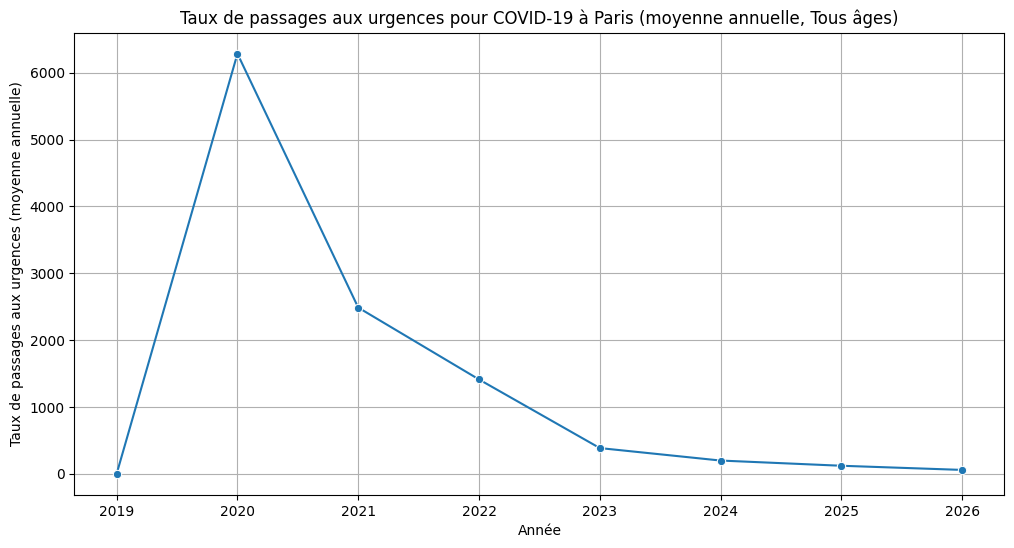

In [15]:
# créer une visualisation des passages aux urgences du covid pour Paris par année
# la colonne 'Année' n'existe pas dans les données : on la crée à partir de '1er jour de la semaine'
# on utilise les lignes "Tous âges" pour ne pas sommer plusieurs classes d'âge
df = paris_data.copy()
df['1er jour de la semaine'] = pd.to_datetime(df['1er jour de la semaine'], errors='coerce')
df['Année'] = df['1er jour de la semaine'].dt.year

# filtrer pour "Tous âges" puis calculer la moyenne annuelle du taux de passages aux urgences
df_tot = df[df["Classe d'âge"] == "Tous âges"]
yearly = df_tot.groupby('Année', as_index=False)['Taux de passages aux urgences pour COVID-19'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly, x='Année', y='Taux de passages aux urgences pour COVID-19', marker='o')
plt.title('Taux de passages aux urgences pour COVID-19 à Paris (moyenne annuelle, Tous âges)')
plt.xlabel('Année')
plt.ylabel('Taux de passages aux urgences (moyenne annuelle)')
plt.grid()
plt.show()

In [ ]:
import pandas as pd

# Chemin du fichier
INPUT = "../Final_data/pics_activité/covid-19-passages-aux-urgences-et-actes-sos-medecins-departement.csv"
OUTPUT = "covid_prets_powerbi.csv"

df = pd.read_csv(INPUT)

# 1) Convertir la colonne date
df["date_semaine"] = pd.to_datetime(df["1er jour de la semaine"], dayfirst=True, errors="coerce")

# 2) Nettoyer la colonne "Semaine" -> extraire le numéro de semaine
# Gère les formats possibles: "2025-S39", "S39", "39", "2025-39", etc.
df["semaine_num"] = (
    df["Semaine"]
    .astype(str)
    .str.extract(r"(\d{1,2})$")[0]   # prend les 1-2 derniers chiffres
    .astype("Int64")
)

# 3) Créer la saison (juillet -> juin)
def build_saison(d):
    if pd.isna(d):
        return None
    y = d.year
    return f"{y}-{y+1}" if d.month >= 7 else f"{y-1}-{y}"

df["saison"] = df["date_semaine"].apply(build_saison)

# 4) Renommer les colonnes pour éviter les accents (Power BI aime bien)
df_out = df.rename(columns={
    "Département Code": "dep_code",
    "Département": "dep",
    "Classe d'âge": "age_classe",
    "Région Code": "region_code",
    "Région": "region",
    "Taux de passages aux urgences pour COVID-19": "taux_passages_urgences_covid",
    "Taux d'hospitalisations après passages aux urgences pour COVID-19": "taux_hosp_apres_urgences_covid",
    "Taux d'actes médicaux SOS médecins pour COVID-19": "taux_actes_sos_covid",
})

# 5) Garder un set de colonnes clean
cols = [
    "region_code", "region",
    "dep_code", "dep",
    "age_classe",
    "saison", "semaine_num", "date_semaine",
    "taux_passages_urgences_covid",
    "taux_hosp_apres_urgences_covid",
    "taux_actes_sos_covid",
]
df_out = df_out[cols]

# 6) Sauvegarder
df_out.to_csv(OUTPUT, index=False, encoding="utf-8")

print("OK ✅ CSV créé:", OUTPUT)
print(df_out.head())


C:\Users\cantfly\AppData\Local\Temp\ipykernel_23880\1338050661.py:10: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date_semaine"] = pd.to_datetime(df["1er jour de la semaine"], dayfirst=True, errors="coerce")


KeyError: "['taux_passages_urgences_covid', 'taux_hosp_apres_urgences_covid', 'taux_actes_sos_covid'] not in index"

In [21]:
#verifier ques les colones taux soient bien des float
print(df_out.dtypes)

region_code                                int64
region                                    object
dep_code                                  object
dep                                       object
age_classe                                object
saison                                    object
semaine_num                                Int64
date_semaine                      datetime64[ns]
taux_passages_urgences_covid             float64
taux_hosp_apres_urgences_covid           float64
taux_actes_sos_covid                     float64
dtype: object


In [19]:
import pandas as pd
from datetime import date

# Charger le CSV original
df = pd.read_csv(
    "../Final_data/pics_activité/covid-19-passages-aux-urgences-et-actes-sos-medecins-departement.csv",
    sep=","
)
print(df.columns.tolist())
# Vérification minimale
required_cols = ["annee", "semaine"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Colonne manquante : {c}")

# 1. Créer la date (lundi de la semaine ISO)
df["date_semaine"] = df.apply(
    lambda r: date.fromisocalendar(
        int(r["annee"]),
        int(r["semaine"]),
        1
    ),
    axis=1
)

# 2. Créer la saison (juillet → juin)
def build_saison(d):
    if d.month >= 7:
        return f"{d.year}-{d.year + 1}"
    else:
        return f"{d.year - 1}-{d.year}"

df["saison"] = df["date_semaine"].apply(build_saison)

# 3. Garder uniquement les colonnes utiles
cols_finales = [
    "region",
    "dep",
    "cl_age90",
    "saison",
    "semaine",
    "date_semaine",
    "taux_pass_corona"
]

cols_finales = [c for c in cols_finales if c in df.columns]
df_final = df[cols_finales]

# 4. Sauvegarder le CSV prêt pour Power BI
df_final.to_csv(
    "urgences_idf_pretes_powerbi.csv",
    index=False
)

print("CSV prêt. Aperçu :")
print(df_final.head())


['1er jour de la semaine', 'Semaine', 'Département Code', 'Département', "Classe d'âge", 'Taux de passages aux urgences pour COVID-19', "Taux d'hospitalisations après passages aux urgences pour COVID-19", "Taux d'actes médicaux SOS médecins pour COVID-19", 'Région Code', 'Région']


ValueError: Colonne manquante : annee